# **EXPERIMENTO - 01**

REGRESSÃO 02 - LASSO (L1) e RIDGE (L2)

In [155]:
# Import das bibliotecas e APIs.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectFromModel

In [156]:
# Import do dataset "winequality-red.csv".

df = np.loadtxt("winequality-red.csv", delimiter=",", skiprows=1)

In [157]:
print (df.shape)

(1599, 12)


In [158]:
nomes_features = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide",
"total sulfur dioxide", "density","pH", "sulphates", "alcohol"]

In [159]:
# Criação da matriz X com as variáveis de entrada e o vetor y com a variável de saída.

X = df[:,0:11]
y = df[:,11]

In [160]:
# Separação do conjunto de treino e teste (70%/30%).

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [161]:
poly = PolynomialFeatures(2, include_bias=False)
X_treino_poly = poly.fit_transform(X_treino)
X_teste_poly = poly.transform(X_teste)

In [162]:
nomes_features_poly = np.array(poly.get_feature_names_out(nomes_features))

In [163]:
# Padronização das variáveis.

padronizacao = StandardScaler().fit(X_treino_poly)
X_treino_padronizado = padronizacao.transform(X_treino_poly)
X_teste_padronizado = padronizacao.transform(X_teste_poly)

In [164]:
# 6. Treinamento do modelo de regressão linear regularizado.
modelo_l1 = Lasso(alpha=0.01, max_iter=10000)
modelo_l1.fit(X_treino_padronizado, y_treino)

# (Em modelos lineares, como a Regressão Linear, o peso da feature é explicitamente representado pelo seu coeficiente)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [165]:
sfm = SelectFromModel(modelo_l1, prefit=True, threshold=1e-5)

In [166]:
X_treino_selecionado = sfm.transform(X_treino_padronizado)
X_teste_selecionado = sfm.transform(X_teste_padronizado)

In [167]:
feat_selecionada = sfm.get_support()
nomes_selecionados = nomes_features_poly[feat_selecionada]

In [168]:
print("\n### Seleção de Features com SelectFromModel ###")
print(f"Total de features iniciais: {len(nomes_features_poly)}")
print(f"Features mantidas: {len(nomes_selecionados)}")
print("\nTop 5 Features Selecionadas:")
print(nomes_selecionados[:5])


### Seleção de Features com SelectFromModel ###
Total de features iniciais: 77
Features mantidas: 19

Top 5 Features Selecionadas:
['alcohol' 'fixed acidity chlorides' 'volatile acidity^2'
 'volatile acidity citric acid' 'volatile acidity residual sugar']


In [169]:
modelo_final = LinearRegression()
modelo_final.fit(X_treino_selecionado, y_treino)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [170]:
y_pred = modelo_final.predict(X_teste_selecionado)
rmse_final = np.sqrt(mean_squared_error(y_teste, y_pred))
r2_final = r2_score(y_teste, y_pred)

In [171]:
array_pesos = modelo_l1.coef_
array_nomes = nomes_features_poly

In [172]:
feat_selecionados = array_pesos != 0
nomes_sel = array_nomes[feat_selecionados]
pesos_sel = array_pesos[feat_selecionados]

In [173]:
pesos_abs = np.abs(pesos_sel)
indices_ordenados = np.argsort(pesos_abs)[::-1]

In [174]:
nomes_finais = nomes_sel[indices_ordenados]
pesos_finais = pesos_sel[indices_ordenados]

In [175]:
print(f"\n## Análise de Seleção de Features (Lasso) ##")
print(f"Total de features geradas (Grau 2): {len(array_nomes)}")
print(f"Features mantidas pelo modelo: {len(nomes_finais)}")
print(f"Features descartadas (peso 0): {len(array_nomes) - len(nomes_finais)}")

print("\n#### Top 10 Features Mais Importantes: ####")
print(f"{'Feature':<30} | {'Peso':>10}")
print("-" * 45)
for nome, peso in zip(nomes_finais[:10], pesos_finais[:10]):
    print(f"{nome:<30} | {peso:10.4f}")


## Análise de Seleção de Features (Lasso) ##
Total de features geradas (Grau 2): 77
Features mantidas pelo modelo: 19
Features descartadas (peso 0): 58

#### Top 10 Features Mais Importantes: ####
Feature                        |       Peso
---------------------------------------------
sulphates alcohol              |     0.2953
total sulfur dioxide sulphates |    -0.2108
alcohol                        |     0.1871
volatile acidity^2             |    -0.1052
volatile acidity pH            |    -0.0876
volatile acidity total sulfur dioxide |     0.0700
free sulfur dioxide alcohol    |     0.0523
chlorides free sulfur dioxide  |    -0.0480
pH^2                           |    -0.0405
residual sugar free sulfur dioxide |     0.0374


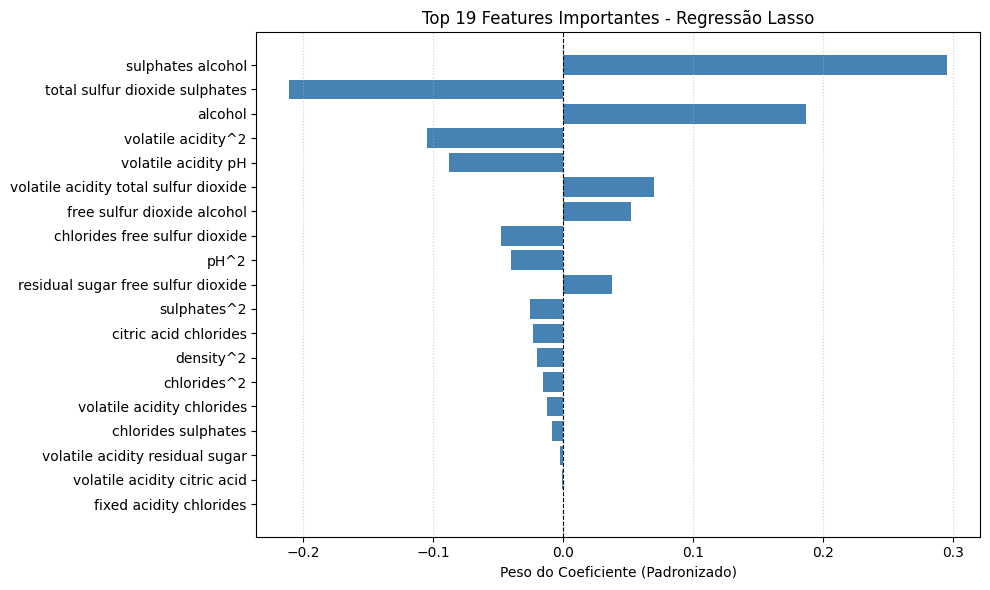

In [176]:
plt.figure(figsize=(10, 6))
k = 19
top_nomes = nomes_finais[:k]
top_pesos = pesos_finais[:k]

plt.barh(top_nomes[::-1], top_pesos[::-1], color='steelblue')

plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title(f"Top {k} Features Importantes - Regressão Lasso")
plt.xlabel("Peso do Coeficiente (Padronizado)")
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [177]:
modelo_ridge = Ridge()
parametros = {"alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

In [178]:
scoring = "neg_mean_squared_error"

grid_search = GridSearchCV(estimator=modelo_ridge, param_grid=parametros, scoring=scoring, cv=5, verbose=1,n_jobs=-1)

In [179]:
print("\n### Iniciando GridSearchCV para encontrar o melhor alpha (Ridge) ###")
grid_search.fit(X_treino_padronizado, y_treino)

melhor_alpha = grid_search.best_params_['alpha']
melhor_neg_mse = grid_search.best_score_
melhor_mse = -melhor_neg_mse 


### Iniciando GridSearchCV para encontrar o melhor alpha (Ridge) ###
Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [180]:
print("\n### Resultados da Otimização ###")
print(f"Melhor coeficiente de regularização (alpha): {melhor_alpha}")
print(f"Melhor MSE (médio na validação cruzada): {melhor_mse:.4f}")


### Resultados da Otimização ###
Melhor coeficiente de regularização (alpha): 100.0
Melhor MSE (médio na validação cruzada): 0.4276


In [183]:
modelo_final_ridge = grid_search.best_estimator_
y_pred_final = modelo_final_ridge.predict(X_teste_padronizado)

rmse_final = np.sqrt(mean_squared_error(y_teste, y_pred_final))
r2_final = grid_search.best_estimator_.score(X_teste_padronizado, y_teste)

print("\n### Métricas no Conjunto de Teste ###")
print(f"Modelo: Ridge (alpha={melhor_alpha})")


### Métricas no Conjunto de Teste ###
Modelo: Ridge (alpha=100.0)


In [182]:
modelo_final_ridge = grid_search.best_estimator_
melhor_alpha = grid_search.best_params_["alpha"]

y_pred_teste = modelo_final_ridge.predict(X_teste_padronizado)

mse_teste = mean_squared_error(y_teste, y_pred_teste)

r2_teste = r2_score(y_teste, y_pred_teste)

print("\n#############################################")
print("### TREINAMENTO E AVALIAÇÃO FINAL (RIDGE) ###")
print("#############################################")
print(f"Modelo Final: Regressão Ridge")
print(f"Hiperparâmetro (Alpha) Otimizado: {melhor_alpha}")
print(f"Número de Features Utilizadas: {X_treino_padronizado.shape[1]}")
print("\n--- Métricas de Desempenho no Conjunto de Teste ---")

print(f"A. Métrica MSE (Erro Quadrático Médio): {mse_teste:.4f}")
print(f"B. Métrica R² (Coeficiente de Determinação): {r2_teste:.4f}")


#############################################
### TREINAMENTO E AVALIAÇÃO FINAL (RIDGE) ###
#############################################
Modelo Final: Regressão Ridge
Hiperparâmetro (Alpha) Otimizado: 100.0
Número de Features Utilizadas: 77

--- Métricas de Desempenho no Conjunto de Teste ---
A. Métrica MSE (Erro Quadrático Médio): 0.3935
B. Métrica R² (Coeficiente de Determinação): 0.3793
